</p>
<h1><b><center></center></b></h1>
<h1><b><center>Mecánica Celeste 2026-1</center></b></h1>
<h3><b><center>Proyecto del Curso:</center></b><h3>
<h2><b><center>La aproximación de Apophis en 2029</center></b><h2>
<h3><b><center>Por Sofía Uribe Rodríguez</center></b></h3>
</p>

## El asteroide Apophis (99942) y su importancia como objeto de análisis y aplicación de conceptos de Mecánica Celeste

El asteroide Apophis (99942) fue descubierto en 2004 y desde entonces se ha rastreado y estudiado debido a que está clasificado como un Near-Earth Asteroid (asteroide cercano a la Tierra) y a su vez como un asteroide potencialmente peligroso, puesto que en abril de 2029 se aproximará a nuestro planeta a una distancia de aproximadamente 32 mil kilómetros, que es menor a la distancia a la que se encuentran algunos satélites en órbita geosincrónica.

Gracias a su paso cercano y a su tamaño de aproximadamente 375 metros, Apophis podrá ser visto a ojo desnudo en el cielo nocturno desde algunas regiones de nuestro planeta. Este evento es sumamente especial y representa una gran oportunidad y motivación para poner en práctica muchos de los conocimientos que un astrónomo va adquiriendo a lo largo de su formación académica.

En este caso, el objetivo es acercarnos a Apophis a través de una mirada enfocada en sus interacciones gravitacionales mayormente clásicas y describirlo por medio de algunos de los conceptos y herramientas computacionales aprendidos en el curso de Mecánica Celeste.

## Definiendo en enfoque


In [2]:
!pip install -Uq pymcel celluloid rebound plotly nbformat

import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
import rebound
from datetime import datetime, timedelta

## **Primera Parte: El Problema de los N-Cuerpos**


**Calculando la Fuerza Gravitacional:**

Comparación entre las magnitudes de la fuerza que ejercen tanto el Sol como la Tierra sobre el asteroide Apophis.

In [5]:
# @title
import warnings
from erfa import ErfaWarning
warnings.filterwarnings('ignore', category=ErfaWarning)

In [24]:
# Elementos del sistema y sus masas
m_tierra = pc.constantes.M_earth
m_sol = pc.constantes.M_sun
m_apophis = 2.3e10  # En kg, masa aproximada

# Distancia de la Tierra al baricentro
tabla, jd, X = pc.consulta_horizons(id='399', location='@SSB', epochs='2029-04-13')
r_tierra = X[0:3]

# Distancia de Apophis al baricentro
tabla, jd, X = pc.consulta_horizons(id='99942', location='@SSB', epochs='2029-04-13')
r_apophis = X[0:3]

#Posición del Sol
tabla, jd, X = pc.consulta_horizons(id='0', location='@SSB', epochs='2029-04-13')
r_sol = X[0:3]

# Distancia entre elementos
r_tierra_sol = r_tierra - r_sol
r_apophis_sol = r_apophis - r_sol
r_tierra_apophis = r_tierra - r_apophis

# Fuerzas
F_apophis_sol = pc.constantes.G * m_apophis * m_sol * r_apophis_sol / np.linalg.norm(r_apophis_sol)**3
F_apophis_sol
F_tierra_apophis = pc.constantes.G * m_tierra * m_apophis * r_tierra_apophis / np.linalg.norm(r_tierra_apophis)**3
F_tierra_apophis

# Comparación
magnitud_F_tierra_apophis = np.linalg.norm(F_tierra_apophis)
magnitud_F_sol_apophis = np.linalg.norm(F_apophis_sol)

print(f"Magnitud de la fuerza del Sol sobre Apophis: {magnitud_F_sol_apophis:.3e} N")
print(f"Magnitud de la fuerza de la Tierra sobre Apophis: {magnitud_F_tierra_apophis:.3e} N")

if magnitud_F_sol_apophis > magnitud_F_tierra_apophis:
    print(f"La fuerza del Sol sobre Apophis es {magnitud_F_sol_apophis / magnitud_F_tierra_apophis:.2f} veces mayor que la fuerza de la Tierra sobre el asteroide.")
elif magnitud_F_tierra_apophis > magnitud_F_sol_apophis:
    print(f"La fuerza de la Tierra sobre Apophis es {magnitud_F_tierra_apophis / magnitud_F_sol_apophis:.2f} veces mayor que la fuerza del Sol sobre el asteroide.")
else:
    print("Ambas fuerzas tienen magnitudes similares.")

Magnitud de la fuerza del Sol sobre Apophis: 1.350e+08 N
Magnitud de la fuerza de la Tierra sobre Apophis: 3.920e+07 N
La fuerza del Sol sobre Apophis es 3.45 veces mayor que la fuerza de la Tierra sobre el asteroide.


**Método de Euler para N-Cuerpos:**

Cálculo de las órbitas de los 3 cuerpos a partir de obtener sus posiciones y velocidades por el método de Euler.

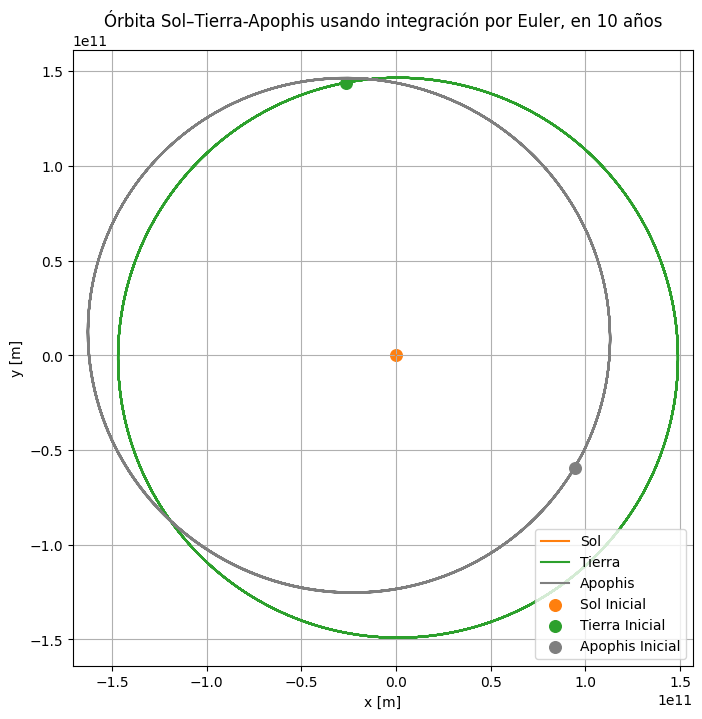

In [10]:
# Posiciones y velocidades iniciales de nuestros 3 elementos
tabla, jd, X_sol = pc.consulta_horizons(id='0', location='@SSB', epochs='2026-01-01 00:00:00')
r_sol_0 = X_sol[:3]
v_sol_0 = X_sol[3:]

tabla, jd, X_tierra = pc.consulta_horizons(id='399', location='@SSB', epochs='2026-01-01 00:00:00')
r_tierra_0 = X_tierra[:3]
v_tierra_0 = X_tierra[3:]

tabla, jd, X_apophis = pc.consulta_horizons(id='99942', location='@SSB', epochs='2026-01-01 00:00:00')
r_apophis_0 = X_apophis[:3]
v_apophis_0 = X_apophis[3:]

# Constantes físicas
G = pc.constantes.G
deltat = 1 * 86400  # un día en segundos

# Masas
m_tierra = pc.constantes.M_earth
m_sol = pc.constantes.M_sun
m_apophis = 2.3e10  # En kg, masa aproximada, como se definió previamente

# Parámetros gravitacionales
mu_sol = pc.constantes.mu_sun
mu_tierra = pc.constantes.mu_earth
mu_apophis = G * m_apophis

years = 10
seconds_per_year = 365.25 * 86400
T_total = years * seconds_per_year
N_steps = int(T_total // deltat)

# Inicializamos posiciones y velocidades con los valores actuales
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()
r_tierra = r_tierra_0.copy()
v_tierra = v_tierra_0.copy()
r_apophis = r_apophis_0.copy()
v_apophis = v_apophis_0.copy()

# Listas para guardar la trayectoria
r_sol_hist = []
r_tierra_hist = []
r_apophis_hist = []

for _ in range(N_steps):
    # Guardamos posiciones actuales
    r_sol_hist.append(r_sol.copy())
    r_tierra_hist.append(r_tierra.copy())
    r_apophis_hist.append(r_apophis.copy())

    # Vectores de separación y sus magnitudes
    r_sol_tierra_vec = r_tierra - r_sol
    norm_sol_tierra = np.linalg.norm(r_sol_tierra_vec)
    r_sol_apophis_vec = r_apophis - r_sol
    norm_sol_apophis = np.linalg.norm(r_sol_apophis_vec)

    r_tierra_sol_vec = r_sol - r_tierra
    norm_tierra_sol = np.linalg.norm(r_tierra_sol_vec)
    r_tierra_apophis_vec = r_apophis - r_tierra
    norm_tierra_apophis = np.linalg.norm(r_tierra_apophis_vec)

    r_apophis_sol_vec = r_sol - r_apophis
    norm_apophis_sol = np.linalg.norm(r_apophis_sol_vec)
    r_apophis_tierra_vec = r_tierra - r_apophis
    norm_apophis_tierra = np.linalg.norm(r_apophis_tierra_vec)

    # Calculamos las aceleraciones para cada cuerpo (suma de las aceleraciones debidas a los otros dos)
    # Aceleración del Sol debido a la Tierra y Apophis
    a_sol = (mu_tierra * r_sol_tierra_vec / norm_sol_tierra**3) + \
            (mu_apophis * r_sol_apophis_vec / norm_sol_apophis**3)

    # Aceleración de la Tierra debido al Sol y Apophis
    a_tierra = (mu_sol * r_tierra_sol_vec / norm_tierra_sol**3) + \
               (mu_apophis * r_tierra_apophis_vec / norm_tierra_apophis**3)

    # Aceleración de Apophis debido al Sol y la Tierra
    a_apophis = (mu_sol * r_apophis_sol_vec / norm_apophis_sol**3) + \
                (mu_tierra * r_apophis_tierra_vec / norm_apophis_tierra**3)

    # Integración tipo Euler
    v_sol = v_sol + a_sol * deltat
    r_sol = r_sol + v_sol * deltat

    v_tierra = v_tierra + a_tierra * deltat
    r_tierra = r_tierra + v_tierra * deltat

    v_apophis = v_apophis + a_apophis * deltat
    r_apophis = r_apophis + v_apophis * deltat

# Convertir las listas de historial a arrays de Numpy
r_sol_hist = np.array(r_sol_hist)
r_tierra_hist = np.array(r_tierra_hist)
r_apophis_hist = np.array(r_apophis_hist)

# Gráfica de órbita en el plano XY
plt.figure(figsize=(8, 8))
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")
plt.plot(r_tierra_hist[:, 0], r_tierra_hist[:, 1], label="Tierra", color="tab:green")
plt.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], label="Apophis", color="tab:gray")

# Posiciones iniciales
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=70, marker="o", label="Sol Inicial")
plt.scatter(r_tierra_0[0], r_tierra_0[1], color="tab:green", s=70, marker="o", label="Tierra Inicial")
plt.scatter(r_apophis_0[0], r_apophis_0[1], color="tab:gray", s=70, marker="o", label="Apophis Inicial")

# Formato de la gráfica
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Órbita Sol–Tierra-Apophis usando integración por Euler, en {years} años")
plt.legend()
plt.axis("equal") # Asegura que los ejes tengan la misma escala
plt.grid(True)
plt.show()

¿Cuáles son los puntos de máximo acercamiento?

Distancia mínima entre la Tierra y Apophis: 1.302e+10 metros
Coordenadas de la Tierra en el punto más cercano: [-2.96624193e+10  1.43314716e+11  1.08206231e+07]
Coordenadas de Apophis en el punto más cercano: [-3.90301382e+10  1.45793210e+11 -8.68645908e+09]


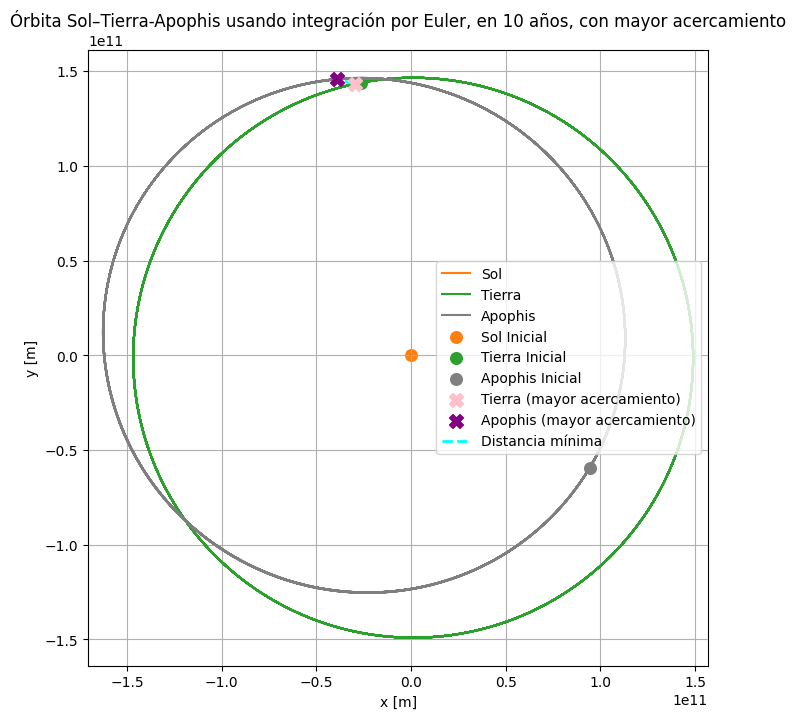

In [11]:
# Calcular las distancias entre la Tierra y Apophis
distances = np.linalg.norm(r_tierra_hist - r_apophis_hist, axis=1)

# Encontrar el índice del mínimo acercamiento
min_distance_idx = np.argmin(distances)
min_distance = distances[min_distance_idx]

# Obtener las coordenadas de la Tierra y Apophis en el punto de mayor acercamiento
closest_tierra_coords = r_tierra_hist[min_distance_idx]
closest_apophis_coords = r_apophis_hist[min_distance_idx]

print(f"Distancia mínima entre la Tierra y Apophis: {min_distance:.3e} metros")
print(f"Coordenadas de la Tierra en el punto más cercano: {closest_tierra_coords}")
print(f"Coordenadas de Apophis en el punto más cercano: {closest_apophis_coords}")

# Re-graficar la órbita en el plano XY añadiendo el punto de mayor acercamiento
plt.figure(figsize=(8, 8))
plt.plot(r_sol_hist[:, 0], r_sol_hist[:, 1], label="Sol", color="tab:orange")
plt.plot(r_tierra_hist[:, 0], r_tierra_hist[:, 1], label="Tierra", color="tab:green")
plt.plot(r_apophis_hist[:, 0], r_apophis_hist[:, 1], label="Apophis", color="tab:gray")

# Posiciones iniciales
plt.scatter(r_sol_0[0], r_sol_0[1], color="tab:orange", s=70, marker="o", label="Sol Inicial")
plt.scatter(r_tierra_0[0], r_tierra_0[1], color="tab:green", s=70, marker="o", label="Tierra Inicial")
plt.scatter(r_apophis_0[0], r_apophis_0[1], color="tab:gray", s=70, marker="o", label="Apophis Inicial")

# Marcamos el punto de mayor acercamiento
plt.scatter(closest_tierra_coords[0], closest_tierra_coords[1], color="pink", s=100, marker="X", label="Tierra (mayor acercamiento)", zorder=3)
plt.scatter(closest_apophis_coords[0], closest_apophis_coords[1], color="purple", s=100, marker="X", label="Apophis (mayor acercamiento)", zorder=3)

# Conectamos los puntos de mayor acercamiento con una línea para visualizarlos
plt.plot([closest_tierra_coords[0], closest_apophis_coords[0]],
         [closest_tierra_coords[1], closest_apophis_coords[1]],
         '--', color='cyan', linewidth=2, label="Distancia mínima")

# Formato de la gráfica
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title(f"Órbita Sol–Tierra-Apophis usando integración por Euler, en {years} años, con mayor acercamiento")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

¿En qué fecha ocurrirá este acercamiento?

In [13]:
# Fecha de inicio de la simulación
start_date_str = '2026-01-01 00:00:00'
start_date = datetime.strptime(start_date_str, '%Y-%m-%d %H:%M:%S')

# Calcular el tiempo transcurrido hasta el punto de mínima distancia
elapsed_seconds = int(min_distance_idx * deltat)
elapsed_time = timedelta(seconds=elapsed_seconds)

# Calcular la fecha del mayor acercamiento
closest_approach_date = start_date + elapsed_time

print(f"La fecha aproximada del mayor acercamiento entre la Tierra y Apophis es: {closest_approach_date}")

La fecha aproximada del mayor acercamiento entre la Tierra y Apophis es: 2028-12-14 00:00:00


*La fecha real de la aproximación corresponde al 13 de abril de 2029. Es decir, hay una discrepancia de aproximadamente 4 meses.*

**Cuadraturas para N cuerpos:**

Primero añadamos una simulación de las trayectorias de los 3 cuerpos usando Rebound, además de visualizar la conservación de la energía total del sistema a los largo de 10 años.

También se encuentran cantidades conservadas, como el Momentum Lineal Total, el Momentum Angular Total y la Energía Total (cinética + potencial).



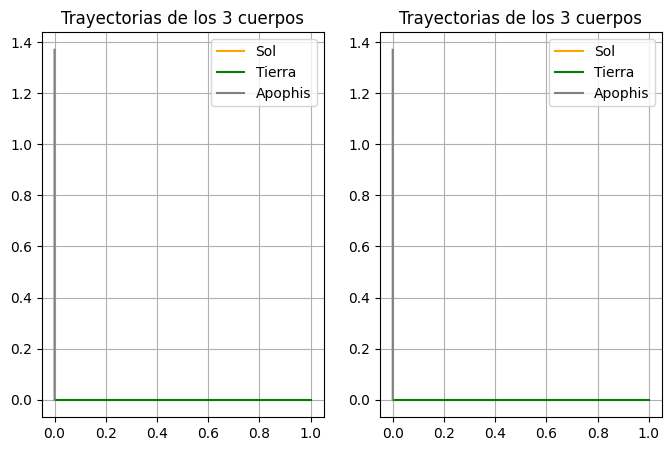

In [50]:
# @title
# Nuestro sistema de 3 cuerpos
sistema = [
    dict(m = m_sol, r = [0, 0, 0], v = [0, 0, 0]),
    dict(m = m_tierra, r = [1, 0, 0], v = [0, 1, 0]),
    dict(m = m_apophis, r = [0, 1.37, 0], v = [0, 0, -1])
]

# Intervalo de tiempo para la integración
ts = np.linspace(0, 10, 200)

# Solución por pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

# Graficación
fig, axs = plt.subplots(1, 2, figsize=(8, 5))

ax = axs[0]
ax.plot(rs[0, :, 0], rs[0, :, 1], label='Sol', color='orange')
ax.plot(rs[1, :, 0], rs[1, :, 1], label='Tierra', color='green')
ax.plot(rs[2, :, 0], rs[2, :, 1], label='Apophis', color='gray')
ax.set_title('Trayectorias de los 3 cuerpos')
ax.legend()
ax.grid()

ax = axs[1]
ax.plot(rps[0, :, 0], rps[0, :, 1], label='Sol', color='orange')
ax.plot(rps[1, :, 0], rps[1, :, 1], label='Tierra', color='green')
ax.plot(rps[2, :, 0], rps[2, :, 1], label='Apophis', color='gray')
ax.set_title('Trayectorias de los 3 cuerpos')
ax.legend()
ax.grid()

plt.show()

# ????

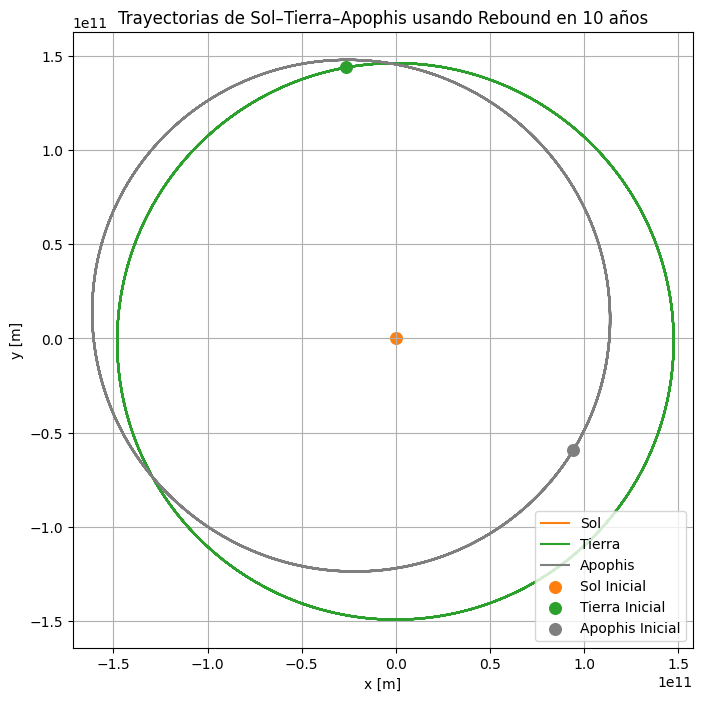

In [56]:
# Simulación por Rebound
sim = rebound.Simulation()

sim.G = pc.constantes.G

# Sol
sim.add(m=m_sol, x=r_sol_0[0], y=r_sol_0[1], z=r_sol_0[2],
        vx=v_sol_0[0], vy=v_sol_0[1], vz=v_sol_0[2])

# Tierra
sim.add(m=m_tierra, x=r_tierra_0[0], y=r_tierra_0[1], z=r_tierra_0[2],
        vx=v_tierra_0[0], vy=v_tierra_0[1], vz=v_tierra_0[2])

# Apophis
sim.add(m=m_apophis, x=r_apophis_0[0], y=r_apophis_0[1], z=r_apophis_0[2],
        vx=v_apophis_0[0], vy=v_apophis_0[1], vz=v_apophis_0[2])

# IAS15 (alta precisión)
sim.integrator = "ias15"

# Duración
years = 10
T_total = years * 365.25 * 86400  # seconds

# Cantidad de puntos
N_outputs = 1000
times = np.linspace(0, T_total, N_outputs)

# Para guardar posiciones y velocidades
rebound_rs = np.zeros((sim.N, N_outputs, 3))
rebound_vs = np.zeros((sim.N, N_outputs, 3))

# Integrar y guardar nuevas posiciones y velocidades
for i, t in enumerate(times):
    sim.integrate(t)
    for j in range(sim.N):
        rebound_rs[j, i, :] = [sim.particles[j].x, sim.particles[j].y, sim.particles[j].z]
        rebound_vs[j, i, :] = [sim.particles[j].vx, sim.particles[j].vy, sim.particles[j].vz]

# Graficación
plt.figure(figsize=(8, 8))
plt.plot(rebound_rs[0, :, 0], rebound_rs[0, :, 1], label='Sol', color='tab:orange')
plt.plot(rebound_rs[1, :, 0], rebound_rs[1, :, 1], label='Tierra', color='tab:green')
plt.plot(rebound_rs[2, :, 0], rebound_rs[2, :, 1], label='Apophis', color='tab:gray')

# Posiciones iniciales
plt.scatter(rebound_rs[0, 0, 0], rebound_rs[0, 0, 1], color="tab:orange", s=70, marker="o", label="Sol Inicial")
plt.scatter(rebound_rs[1, 0, 0], rebound_rs[1, 0, 1], color="tab:green", s=70, marker="o", label="Tierra Inicial")
plt.scatter(rebound_rs[2, 0, 0], rebound_rs[2, 0, 1], color="tab:gray", s=70, marker="o", label="Apophis Inicial")

plt.title(f'Trayectorias de Sol–Tierra–Apophis usando Rebound en {years} años')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Las cantidades obtenidas por cuadraturas:

In [68]:
def calculate_conservation_quantities(simulation):
    MLT = np.array([0.0, 0.0, 0.0])  # Momentum lineal total
    MAT = np.array([0.0, 0.0, 0.0])  # Momentum angular total
    K = 0.0  # Energía mecánica
    U = 0.0  # Energía potencial
    I = 0.0  # Momento de Inercia (respecto al origen)

    # MLT, MAT, K, I
    for p in simulation.particles:
        pos = np.array([p.x, p.y, p.z])
        vel = np.array([p.vx, p.vy, p.vz])
        MLT += p.m * vel
        MAT += p.m * np.cross(pos, vel)
        K += 0.5 * p.m * np.sum(vel**2)
        I += p.m * np.sum(pos**2)

    # U (en los 3 pares)
    for i in range(simulation.N):
        for j in range(i + 1, simulation.N):
            p1 = simulation.particles[i]
            p2 = simulation.particles[j]
            r_vec = np.array([p1.x - p2.x, p1.y - p2.y, p1.z - p2.z])
            dist = np.linalg.norm(r_vec)
            if dist > 0:  # Evita /0 (cuando están en el mismo punto)
                U -= simulation.G * p1.m * p2.m / dist

    E = K + U
    return MLT, MAT, K, U, E, I

# Estado inicial nuevo
MLT_initial, MAT_initial, K_initial, U_initial, E_initial, I_initial = calculate_conservation_quantities(initial_sim)
print("\nEstado Inicial del Sistema (t=0):")
print(f"Momentum Lineal Total: {MLT_initial}")
print(f"Momentum Angular Total: {MAT_initial}")
print(f"Energía Mecánica: {K_initial}")
print(f"Energía Potencial: {U_initial}")
print(f"Energía Total: {E_initial}")
print(f"Momento de Inercia: {I_initial}")

# Estado final (10 años)
MLT_final, MAT_final, K_final, U_final, E_final, I_final = calculate_conservation_quantities(sim)
print("\nEstado Final (t=10 años) del Sistema:")
print(f"Momentum Lineal Total: {MLT_final}")
print(f"Momentum Angular Total: {MAT_final}")
print(f"Energía Mecánica: {K_final}")
print(f"Energía Potencial: {U_final}")
print(f"Energía Total: {E_final}")
print(f"Momento de Inercia: {I_final}")


Estado Inicial del Sistema (t=0):
Momentum Lineal Total: [-1.77830293e+29 -3.22255948e+28  1.04742042e+24]
Momentum Angular Total: [ 4.99028903e+35 -1.89398963e+36  2.64530967e+40]
Energía Mecánica: 2.7345264559647866e+33
Energía Potencial: -5.41486006572647e+33
Energía Total: -2.680333609761683e+33
Momento de Inercia: 1.2795133220371627e+47

Estado Final (t=10 años) del Sistema:
Momentum Lineal Total: [-1.77830293e+29 -3.22255948e+28  1.04742042e+24]
Momentum Angular Total: [ 4.99028903e+35 -1.89398963e+36  2.64530967e+40]
Energía Mecánica: 2.689100990098532e+33
Energía Potencial: -5.369434599860215e+33
Energía Total: -2.6803336097616827e+33
Momento de Inercia: 1.3176142764353784e+47


Evolución de la energía total:

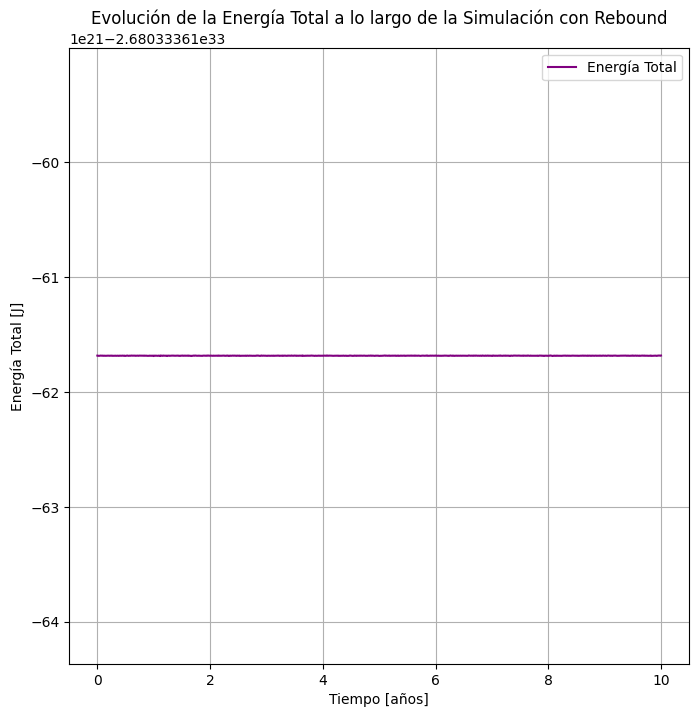

In [64]:
total_energies = []

# Crea simulación dummy
dummy_sim = rebound.Simulation()
dummy_sim.G = pc.constantes.G

# Los cuerpos y sus masas
dummy_sim.add(m=m_sol)
dummy_sim.add(m=m_tierra)
dummy_sim.add(m=m_apophis)


for i in range(N_outputs):
    # Nuevas posiciones y velocidades
    for j in range(dummy_sim.N):
        p = dummy_sim.particles[j]
        p.x, p.y, p.z = rebound_rs[j, i, :]
        p.vx, p.vy, p.vz = rebound_vs[j, i, :]

    _, _, _, _, E_current = calculate_conservation_quantities(dummy_sim)
    total_energies.append(E_current)

# Graficar
plt.figure(figsize=(8, 8))
plt.plot(times / (365.25 * 86400), total_energies, label='Energía Total', color='purple') # Convertir t a años
plt.xlabel('Tiempo [años]')
plt.ylabel('Energía Total [J]')
plt.title('Evolución de la Energía Total a lo largo de la Simulación con Rebound')
plt.grid(True)
plt.legend()

*Que la energía total corresponda a un valor negativo implica que el sistema está ligado y ninguno de los 3 cuerpos saldrá expulsado. Además, como se puede ver, permanece constante a lo largo del tiempo*

**Sistemas Jerárquicos:**

In [ ]:
sim_solar = rb.Simulation()
sim_solar.add('Sun',date='1975-06-19')
sim_solar.add('Earth',date='1975-06-19')
sim_solar.add('Apophis',date='1975-06-19')

-No virial
-No t de relajación
-No toomre
-No sistemas anómalos


## Referencias
https://science.nasa.gov/solar-system/asteroids/apophis/

https://www.esa.int/Space_Safety/Planetary_Defence/Apophis

https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=apophis
